# Daily one-hour cross-variogram diagnostic, 2022-2025 July

This notebook adapts the style and definition from `emp_and_fitted_cv_v05_122525.ipynb` for a three-model comparison.

For each July day in 2022-2025, one figure is saved with two panels:

- latitude-lag one-hour cross-variogram
- longitude-lag one-hour cross-variogram

Each daily plot shows:

- 7 blue empirical one-hour cross-variogram curves, one for each adjacent hour pair among 8 hourly slots
- thick black empirical average across the 7 adjacent hour pairs
- three fitted one-hour cross-variogram curves implied by the model estimates

The empirical object is

```text
gamma_hat(h, tau=1) = 0.5 * mean{ r(s,t) - r(s+h,t+1) }^2
```

The fitted model curve uses the same sign convention, so its minimum is expected near `h = fitted_advection * tau`.


In [1]:
import os
import pickle
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
DATA_ROOT = Path('/Users/joonwonlee/Documents/GEMS_DATA')

YEARS = [2022, 2023, 2024, 2025]
MONTH = 7
COMMON_DAYS = list(range(1, 29))
LAT_RANGE = [-3.0, 2.0]
LON_RANGE = [121.0, 131.0]
CENTER_MODE = 'hourly_mean'
TAU = 1.0
SMOOTH = 0.5
CROSS_Y_MAX = 30.0

# Signed lag grids copied from the empirical cross-variogram workflow.
LAT_CROSS_LAGS = np.concatenate([
    -np.arange(0.176, 2.3, 0.044 * 5)[::-1],
    [-0.132, -0.044, 0.0, 0.044, 0.132],
    np.arange(0.176, 2.3, 0.044 * 5),
])
LON_CROSS_LAGS = np.concatenate([
    -np.arange(0.18, 2.0, 0.063 * 3)[::-1],
    [-0.126, -0.063, 0.0, 0.063, 0.126],
    np.arange(0.18, 2.0, 0.063 * 3),
])
LAT_CROSS_LAGS = np.round(LAT_CROSS_LAGS, 3)
LON_CROSS_LAGS = np.round(LON_CROSS_LAGS, 3)

ESTIMATE_FILES = {
    'Vecchia_mm20': PROJECT_ROOT / 'outputs/day/july_22_23_24_25/real_vecc_july_22_23_24_25_mm20.csv',
    'Debiased_Whittle': PROJECT_ROOT / 'outputs/day/july_22_23_24_25/real_dw_july_22_23_24_25.csv',
    'Corridor_4x4_lag643': PROJECT_ROOT / 'outputs/day/july_22_23_24_25/real_july_corridor_width_4x4_lag643_all_fits.csv',
}

OUTPUT_DIR = PROJECT_ROOT / 'plots/directional_semivariograms/daily_cross_variograms_three_model_2022_2025_052626'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Output directory: {OUTPUT_DIR}')
print('lat cross lags:', LAT_CROSS_LAGS)
print('lon cross lags:', LON_CROSS_LAGS)


Output directory: /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_cross_variograms_three_model_2022_2025_052626
lat cross lags: [-2.156 -1.936 -1.716 -1.496 -1.276 -1.056 -0.836 -0.616 -0.396 -0.176
 -0.132 -0.044  0.     0.044  0.132  0.176  0.396  0.616  0.836  1.056
  1.276  1.496  1.716  1.936  2.156]
lon cross lags: [-1.881 -1.692 -1.503 -1.314 -1.125 -0.936 -0.747 -0.558 -0.369 -0.18
 -0.126 -0.063  0.     0.063  0.126  0.18   0.369  0.558  0.747  0.936
  1.125  1.314  1.503  1.692  1.881]


In [2]:
def parse_day_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'day' in df.columns:
        parsed = df['day'].astype(str).str.extract(r'(?P<year>\d{4})-(?P<month>\d{1,2})-(?P<day_num>\d{1,2})')
        for col in ['year', 'month', 'day_num']:
            if col not in df.columns or df[col].isna().all():
                df[col] = pd.to_numeric(parsed[col], errors='coerce').astype('Int64')
    elif {'year', 'month', 'day_idx'}.issubset(df.columns):
        df['day_num'] = pd.to_numeric(df['day_idx'], errors='coerce').astype('Int64') + 1
    return df


def load_one_estimate_file(model_name: str, path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path)
    raw = parse_day_columns(raw)
    if 'status' in raw.columns:
        raw = raw.loc[raw['status'].astype(str).str.lower().eq('ok')].copy()

    if {'est_sigmasq', 'est_range_lat', 'est_range_lon', 'est_range_time', 'est_advec_lat', 'est_advec_lon', 'est_nugget'}.issubset(raw.columns):
        mapped = pd.DataFrame({
            'model': model_name,
            'year': raw['year'],
            'month': raw['month'],
            'day_num': raw['day_num'],
            'day': raw['day'],
            'cov_name': raw.get('spec_name', model_name),
            'sigma': raw['est_sigmasq'],
            'range_lat': raw['est_range_lat'],
            'range_lon': raw['est_range_lon'],
            'range_time': raw['est_range_time'],
            'advec_lat': raw['est_advec_lat'],
            'advec_lon': raw['est_advec_lon'],
            'nugget': raw['est_nugget'],
            'loss': raw.get('loss', np.nan),
            'time': raw.get('total_s', raw.get('time', np.nan)),
        })
    else:
        mapped = pd.DataFrame({
            'model': model_name,
            'year': raw['year'],
            'month': raw['month'],
            'day_num': raw['day_num'],
            'day': raw['day'],
            'cov_name': raw.get('cov_name', model_name),
            'sigma': raw['sigma'],
            'range_lat': raw['range_lat'],
            'range_lon': raw['range_lon'],
            'range_time': raw['range_time'],
            'advec_lat': raw['advec_lat'],
            'advec_lon': raw['advec_lon'],
            'nugget': raw['nugget'],
            'loss': raw.get('loss', np.nan),
            'time': raw.get('time', np.nan),
        })

    numeric_cols = ['year', 'month', 'day_num', 'sigma', 'range_lat', 'range_lon', 'range_time', 'advec_lat', 'advec_lon', 'nugget', 'loss', 'time']
    for col in numeric_cols:
        mapped[col] = pd.to_numeric(mapped[col], errors='coerce')
    return mapped


def load_all_estimates(files: Dict[str, Path]) -> pd.DataFrame:
    frames = [load_one_estimate_file(name, path) for name, path in files.items()]
    out = pd.concat(frames, ignore_index=True)
    out = out.loc[out['year'].isin(YEARS) & out['month'].eq(MONTH) & out['day_num'].isin(COMMON_DAYS)].copy()
    out = out.sort_values(['year', 'day_num', 'model']).reset_index(drop=True)
    return out


estimates = load_all_estimates(ESTIMATE_FILES)
param_cols = ['year', 'model', 'day', 'sigma', 'range_lat', 'range_lon', 'range_time', 'advec_lat', 'advec_lon', 'nugget', 'loss', 'time']
param_table = estimates[param_cols].round(4)
param_csv = OUTPUT_DIR / 'three_model_parameter_estimates_2022_2025_07.csv'
param_table.to_csv(param_csv, index=False, float_format='%.4f')
print(f'Saved {param_csv}')
display(param_table.head(12))


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_cross_variograms_three_model_2022_2025_052626/three_model_parameter_estimates_2022_2025_07.csv


,year,model,day,sigma,range_lat,range_lon,range_time,advec_lat,advec_lon,nugget,loss,time
0,2022,Corridor_4x4_lag643,2022-07-01,3.9851,0.1194,0.1515,1.1154,0.0038,-0.0223,2.2072,1.2093,35.4315
1,2022,Debiased_Whittle,2022-07-1,3.5972,0.1418,0.2201,1.2601,-0.0156,0.0799,2.4864,115551.0880,111.7636
2,2022,Vecchia_mm20,2022-07-1,3.4937,0.1703,0.2118,1.6525,-0.0009,-0.0269,2.6723,1.2591,54.4569
3,2022,Corridor_4x4_lag643,2022-07-02,7.0359,0.1715,0.1787,1.0242,0.0075,-0.2795,1.8939,1.2553,24.8630
4,2022,Debiased_Whittle,2022-07-2,6.4137,0.1200,0.1311,0.8784,0.0299,-0.2897,1.4776,246956.5280,94.1755
5,2022,Vecchia_mm20,2022-07-2,7.8296,0.3299,0.3572,1.6104,0.0263,-0.1932,2.6110,1.3469,39.9762
6,2022,Corridor_4x4_lag643,2022-07-03,8.8221,0.1898,0.2358,1.0405,0.0182,-0.1128,1.5376,1.2257,21.7607
7,2022,Debiased_Whittle,2022-07-3,5.9562,0.1507,0.1610,0.8402,0.0092,-0.0588,1.0284,-79128.9280,75.2054
8,2022,Vecchia_mm20,2022-07-3,10.2319,0.3491,0.5161,1.8609,0.0359,-0.1294,2.2946,1.3337,33.3842
9,2022,Corridor_4x4_lag643,2022-07-04,7.6722,0.1842,0.1821,1.2079,0.0455,-0.1758,2.1201,1.2960,27.8050


In [3]:
DATA_CACHE = {}
GRID_CACHE = {}


def load_year_raw_map(year: int) -> Dict[str, pd.DataFrame]:
    if year not in DATA_CACHE:
        path = DATA_ROOT / f'pickle_{year}' / f'tco_grid_{str(year)[2:]}_{MONTH:02d}.pkl'
        with open(path, 'rb') as f:
            DATA_CACHE[year] = pickle.load(f)
        print(f'Loaded {len(DATA_CACHE[year])} hourly maps for {year}-{MONTH:02d}')
    return DATA_CACHE[year]


def build_grid_meta(year: int):
    if year in GRID_CACHE:
        return GRID_CACHE[year]
    raw = load_year_raw_map(year)
    first_key = sorted(raw)[0]
    df = raw[first_key].copy()
    mask = (
        df['Latitude'].between(LAT_RANGE[0], LAT_RANGE[1])
        & df['Longitude'].between(LON_RANGE[0], LON_RANGE[1])
    ).to_numpy()
    sub = df.loc[mask].copy()
    lats = np.sort(sub['Latitude'].round(6).unique())
    lons = np.sort(sub['Longitude'].round(6).unique())
    lat_to_i = {float(v): i for i, v in enumerate(lats)}
    lon_to_j = {float(v): j for j, v in enumerate(lons)}
    lat_idx = sub['Latitude'].round(6).map(lat_to_i).to_numpy(dtype=int)
    lon_idx = sub['Longitude'].round(6).map(lon_to_j).to_numpy(dtype=int)
    meta = {
        'mask': mask,
        'lats': lats,
        'lons': lons,
        'lat_idx': lat_idx,
        'lon_idx': lon_idx,
        'lat_step': float(np.nanmedian(np.diff(lats))),
        'lon_step': float(np.nanmedian(np.diff(lons))),
    }
    GRID_CACHE[year] = meta
    print(f'{year}: grid shape={len(lats)}x{len(lons)}, lat_step={meta["lat_step"]:.4f}, lon_step={meta["lon_step"]:.4f}')
    return meta


def dataframe_to_centered_grid(df: pd.DataFrame, meta: dict) -> np.ndarray:
    vals = pd.to_numeric(df.loc[meta['mask'], 'ColumnAmountO3'], errors='coerce').to_numpy(dtype=float)
    if CENTER_MODE == 'hourly_mean':
        vals = vals - np.nanmean(vals)
    elif CENTER_MODE == 'none':
        pass
    else:
        raise ValueError(f'Unknown CENTER_MODE={CENTER_MODE}')
    grid = np.full((len(meta['lats']), len(meta['lons'])), np.nan, dtype=float)
    grid[meta['lat_idx'], meta['lon_idx']] = vals
    return grid


def keys_for_day(raw_map: Dict[str, pd.DataFrame], day: int):
    token = f'day{int(day):02d}'
    return [k for k in sorted(raw_map) if token in k]


In [4]:
def shifted_cross_semivariance(cur: np.ndarray, nxt: np.ndarray, di: int, dj: int) -> Tuple[float, int]:
    """0.5 * mean{cur(s) - nxt(s+h)}^2 for grid offset h=(di,dj)."""
    nlat, nlon = cur.shape
    if abs(di) >= nlat or abs(dj) >= nlon:
        return np.nan, 0

    if di >= 0:
        cur_i = slice(0, nlat - di)
        nxt_i = slice(di, nlat)
    else:
        cur_i = slice(-di, nlat)
        nxt_i = slice(0, nlat + di)

    if dj >= 0:
        cur_j = slice(0, nlon - dj)
        nxt_j = slice(dj, nlon)
    else:
        cur_j = slice(-dj, nlon)
        nxt_j = slice(0, nlon + dj)

    a = cur[cur_i, cur_j]
    b = nxt[nxt_i, nxt_j]
    mask = np.isfinite(a) & np.isfinite(b)
    n = int(mask.sum())
    if n == 0:
        return np.nan, 0
    diff = a[mask] - b[mask]
    return float(0.5 * np.mean(diff * diff)), n


def compute_day_empirical_cross_variogram(year: int, day: int):
    raw = load_year_raw_map(year)
    meta = build_grid_meta(year)
    day_keys = keys_for_day(raw, day)
    if len(day_keys) < 8:
        print(f'Warning: {year}-07-{day:02d} has {len(day_keys)} hourly maps')
    day_keys = day_keys[:8]
    grids = [dataframe_to_centered_grid(raw[key], meta) for key in day_keys]

    lat_offsets = [int(round(float(lag) / meta['lat_step'])) for lag in LAT_CROSS_LAGS]
    lon_offsets = [int(round(float(lag) / meta['lon_step'])) for lag in LON_CROSS_LAGS]

    lat_pairs = []
    lon_pairs = []
    lat_counts = []
    lon_counts = []
    pair_labels = []

    for h in range(max(0, len(grids) - 1)):
        cur = grids[h]
        nxt = grids[h + 1]
        lat_vals, lat_ns = zip(*[shifted_cross_semivariance(cur, nxt, off, 0) for off in lat_offsets])
        lon_vals, lon_ns = zip(*[shifted_cross_semivariance(cur, nxt, 0, off) for off in lon_offsets])
        lat_pairs.append(lat_vals)
        lon_pairs.append(lon_vals)
        lat_counts.append(lat_ns)
        lon_counts.append(lon_ns)
        pair_labels.append(f'Hour {h + 1} to {h + 2}')

    lat_pairs = np.asarray(lat_pairs, dtype=float)
    lon_pairs = np.asarray(lon_pairs, dtype=float)
    lat_counts = np.asarray(lat_counts, dtype=int)
    lon_counts = np.asarray(lon_counts, dtype=int)

    return {
        'year': year,
        'day': day,
        'hour_keys': day_keys,
        'pair_labels': pair_labels,
        'lat_lags': LAT_CROSS_LAGS,
        'lon_lags': LON_CROSS_LAGS,
        'lat_pairs': lat_pairs,
        'lon_pairs': lon_pairs,
        'lat_mean': np.nanmean(lat_pairs, axis=0),
        'lon_mean': np.nanmean(lon_pairs, axis=0),
        'lat_counts': lat_counts,
        'lon_counts': lon_counts,
    }


In [5]:
MODEL_STYLE = {
    'Vecchia_mm20': {'label': 'Vecchia mm20', 'color': '#d62728', 'linestyle': '--'},
    'Debiased_Whittle': {'label': 'Debiased Whittle', 'color': '#2ca02c', 'linestyle': '--'},
    'Corridor_4x4_lag643': {'label': 'Corridor 4x4', 'color': '#111111', 'linestyle': '--'},
}
BLUE_COLORS = [
    (222/255, 235/255, 247/255),
    (198/255, 219/255, 239/255),
    (158/255, 202/255, 225/255),
    (107/255, 174/255, 214/255),
    (66/255, 146/255, 198/255),
    (33/255, 113/255, 181/255),
    (8/255, 69/255, 148/255),
]


def fitted_cross_variogram(lags: np.ndarray, row: pd.Series, direction: str, tau: float = TAU) -> np.ndarray:
    sigmasq = float(row['sigma'])
    nugget = float(row['nugget'])
    range_lat = max(float(row['range_lat']), 1e-12)
    range_lon = max(float(row['range_lon']), 1e-12)
    range_time = max(float(row['range_time']), 1e-12)
    advec_lat = float(row['advec_lat'])
    advec_lon = float(row['advec_lon'])

    h = np.asarray(lags, dtype=float)
    if direction == 'lat':
        lat_diff = h
        lon_diff = np.zeros_like(h)
    elif direction == 'lon':
        lat_diff = np.zeros_like(h)
        lon_diff = h
    else:
        raise ValueError(direction)

    distance = np.sqrt(
        ((lat_diff - advec_lat * tau) / range_lat) ** 2
        + ((lon_diff - advec_lon * tau) / range_lon) ** 2
        + (tau / range_time) ** 2
    )
    if np.isclose(SMOOTH, 0.5):
        corr = np.exp(-distance)
    elif np.isclose(SMOOTH, 1.5):
        corr = (1.0 + distance) * np.exp(-distance)
    else:
        raise ValueError('This notebook implements smooth 0.5 or 1.5 for fitted curves.')
    return nugget + sigmasq * (1.0 - corr)


def estimate_rows_for_day(year: int, day: int) -> pd.DataFrame:
    return estimates.loc[estimates['year'].eq(year) & estimates['day_num'].eq(day)].copy()


def summarize_curve_error(year: int, day: int, emp: dict):
    rows = []
    est_day = estimate_rows_for_day(year, day)
    for direction, lags, empirical_mean in [
        ('lat', emp['lat_lags'], emp['lat_mean']),
        ('lon', emp['lon_lags'], emp['lon_mean']),
    ]:
        for _, est in est_day.iterrows():
            fitted = fitted_cross_variogram(np.asarray(lags), est, direction)
            valid = np.isfinite(empirical_mean) & np.isfinite(fitted)
            residual = empirical_mean[valid] - fitted[valid]
            rows.append({
                'year': year,
                'month': MONTH,
                'day_num': day,
                'direction': direction,
                'model': est['model'],
                'rmse': float(np.sqrt(np.mean(residual ** 2))) if residual.size else np.nan,
                'mae': float(np.mean(np.abs(residual))) if residual.size else np.nan,
                'bias_emp_minus_fit': float(np.mean(residual)) if residual.size else np.nan,
                'sigma': est['sigma'],
                'range_lat': est['range_lat'],
                'range_lon': est['range_lon'],
                'range_time': est['range_time'],
                'advec_lat': est['advec_lat'],
                'advec_lon': est['advec_lon'],
                'nugget': est['nugget'],
            })
    return rows


In [6]:
def plot_day_cross_variogram(year: int, day: int, emp: dict, out_dir: Path, save=True):
    fig, axes = plt.subplots(1, 2, figsize=(16.0, 6.4), constrained_layout=True)
    est_day = estimate_rows_for_day(year, day)

    panels = [
        ('lat', 'Latitude-lag cross-variogram, tau=1', emp['lat_lags'], emp['lat_pairs'], emp['lat_mean']),
        ('lon', 'Longitude-lag cross-variogram, tau=1', emp['lon_lags'], emp['lon_pairs'], emp['lon_mean']),
    ]

    for ax, (direction, title, lags, pair_values, pair_mean) in zip(axes, panels):
        for h in range(min(7, pair_values.shape[0])):
            ax.plot(lags, pair_values[h], color=BLUE_COLORS[h], lw=1.25, alpha=0.88, label=f'Hour {h + 1} to {h + 2}')
        ax.plot(lags, pair_mean, color='black', lw=3.2, label='Mean over 7 one-hour pairs', zorder=6)

        dense_lags = np.linspace(float(np.nanmin(lags)), float(np.nanmax(lags)), 320)
        for _, est in est_day.iterrows():
            style = MODEL_STYLE.get(est['model'], {'label': est['model'], 'color': '0.25', 'linestyle': '--'})
            fitted = fitted_cross_variogram(dense_lags, est, direction)
            ax.plot(
                dense_lags, fitted,
                color=style['color'], linestyle=style['linestyle'], lw=2.3,
                label=f'{style["label"]} fitted tau=1', zorder=5,
            )

        ax.axvline(0, color='0.45', linestyle=':', lw=1.0)
        ax.set_ylim(0, CROSS_Y_MAX)
        ax.set_xlim(float(np.nanmin(lags)), float(np.nanmax(lags)))
        ax.set_xlabel(f'{direction} lag (degrees)')
        ax.set_ylabel('cross-semivariance')
        ax.set_title(title)
        ax.grid(True, alpha=0.32)

    fig.suptitle(f'{year}-07-{day:02d}: empirical one-hour cross-variogram vs fitted models', fontsize=15)
    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=8.3, frameon=True, bbox_to_anchor=(0.5, -0.065))
    if save:
        out_path = out_dir / f'daily_cross_variogram_three_models_{year}_07_day{day:02d}.png'
        fig.savefig(out_path, bbox_inches='tight')
    return fig


In [7]:
RUN_ALL = True
SHOW_EACH_DAY = False

all_empirical_rows = []
all_fit_rows = []
all_error_rows = []

if RUN_ALL:
    for year in YEARS:
        year_dir = OUTPUT_DIR / f'year_{year}'
        daily_dir = year_dir / 'daily_cross_variograms'
        year_dir.mkdir(parents=True, exist_ok=True)
        daily_dir.mkdir(parents=True, exist_ok=True)
        pdf_path = year_dir / f'daily_cross_variogram_three_models_{year}_07_days01_28.pdf'
        print(f'\n=== Processing {year}-07 ===')
        with PdfPages(pdf_path) as pdf:
            for day in COMMON_DAYS:
                print(f'Processing {year}-07-{day:02d}...')
                emp = compute_day_empirical_cross_variogram(year, day)
                for direction, lags, pair_values, pair_mean, counts in [
                    ('lat', emp['lat_lags'], emp['lat_pairs'], emp['lat_mean'], emp['lat_counts']),
                    ('lon', emp['lon_lags'], emp['lon_pairs'], emp['lon_mean'], emp['lon_counts']),
                ]:
                    for j, lag in enumerate(lags):
                        row = {
                            'year': year,
                            'month': MONTH,
                            'day_num': day,
                            'direction': direction,
                            'lag': float(lag),
                            'mean_over_7_pairs': float(pair_mean[j]) if np.isfinite(pair_mean[j]) else np.nan,
                            'mean_pair_count': float(np.nanmean(counts[:, j])),
                        }
                        for h in range(pair_values.shape[0]):
                            row[f'pair_{h + 1}_{h + 2}'] = float(pair_values[h, j]) if np.isfinite(pair_values[h, j]) else np.nan
                            row[f'n_pairs_{h + 1}_{h + 2}'] = int(counts[h, j])
                        all_empirical_rows.append(row)

                est_day = estimate_rows_for_day(year, day)
                for direction, lags in [('lat', emp['lat_lags']), ('lon', emp['lon_lags'])]:
                    for _, est in est_day.iterrows():
                        fitted = fitted_cross_variogram(np.asarray(lags), est, direction)
                        for lag, gamma in zip(lags, fitted):
                            all_fit_rows.append({
                                'year': year,
                                'month': MONTH,
                                'day_num': day,
                                'direction': direction,
                                'lag': float(lag),
                                'model': est['model'],
                                'fitted_gamma_tau1': float(gamma),
                                'sigma': est['sigma'],
                                'range_lat': est['range_lat'],
                                'range_lon': est['range_lon'],
                                'range_time': est['range_time'],
                                'advec_lat': est['advec_lat'],
                                'advec_lon': est['advec_lon'],
                                'nugget': est['nugget'],
                            })
                all_error_rows.extend(summarize_curve_error(year, day, emp))

                fig = plot_day_cross_variogram(year, day, emp, daily_dir, save=True)
                pdf.savefig(fig, bbox_inches='tight')
                if SHOW_EACH_DAY:
                    plt.show()
                else:
                    plt.close(fig)
        print(f'Saved {pdf_path}')

empirical_table = pd.DataFrame(all_empirical_rows).round(4)
fitted_table = pd.DataFrame(all_fit_rows).round(4)
error_table = pd.DataFrame(all_error_rows).round(4)

empirical_csv = OUTPUT_DIR / 'empirical_daily_one_hour_cross_variogram_2022_2025_07.csv'
fitted_csv = OUTPUT_DIR / 'fitted_tau1_cross_variogram_three_models_2022_2025_07.csv'
error_csv = OUTPUT_DIR / 'cross_variogram_model_curve_error_2022_2025_07.csv'
empirical_table.to_csv(empirical_csv, index=False, float_format='%.4f')
fitted_table.to_csv(fitted_csv, index=False, float_format='%.4f')
error_table.to_csv(error_csv, index=False, float_format='%.4f')
print(f'Saved {empirical_csv}')
print(f'Saved {fitted_csv}')
print(f'Saved {error_csv}')

for year in YEARS:
    year_dir = OUTPUT_DIR / f'year_{year}'
    empirical_table.loc[empirical_table['year'].eq(year)].to_csv(year_dir / f'empirical_daily_one_hour_cross_variogram_{year}_07.csv', index=False, float_format='%.4f')
    fitted_table.loc[fitted_table['year'].eq(year)].to_csv(year_dir / f'fitted_tau1_cross_variogram_three_models_{year}_07.csv', index=False, float_format='%.4f')
    error_table.loc[error_table['year'].eq(year)].to_csv(year_dir / f'cross_variogram_model_curve_error_{year}_07.csv', index=False, float_format='%.4f')

display(error_table.head(12))



=== Processing 2022-07 ===
Processing 2022-07-01...
Loaded 240 hourly maps for 2022-07
2022: grid shape=114x159, lat_step=0.0440, lon_step=0.0630


Processing 2022-07-02...


Processing 2022-07-03...


Processing 2022-07-04...


Processing 2022-07-05...


...

Processing 2025-07-26...


Processing 2025-07-27...


Processing 2025-07-28...


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_cross_variograms_three_model_2022_2025_052626/year_2025/daily_cross_variogram_three_models_2025_07_days01_28.pdf
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_cross_variograms_three_model_2022_2025_052626/empirical_daily_one_hour_cross_variogram_2022_2025_07.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_cross_variograms_three_model_2022_2025_052626/fitted_tau1_cross_variogram_three_models_2022_2025_07.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_cross_variograms_three_model_2022_2025_052626/cross_variogram_model_curve_error_2022_2025_07.csv


,year,month,day_num,direction,model,rmse,mae,bias_emp_minus_fit,sigma,range_lat,range_lon,range_time,advec_lat,advec_lon,nugget
0,2022,7,1,lat,Corridor_4x4_lag643,3.1003,2.1278,2.1209,3.9851,0.1194,0.1515,1.1154,0.0038,-0.0223,2.2072
1,2022,7,1,lat,Debiased_Whittle,3.1776,2.2448,2.2376,3.5972,0.1418,0.2201,1.2601,-0.0156,0.0799,2.4864
2,2022,7,1,lat,Vecchia_mm20,3.1320,2.2594,2.2594,3.4937,0.1703,0.2118,1.6525,-0.0009,-0.0269,2.6723
3,2022,7,1,lon,Corridor_4x4_lag643,0.2592,0.1942,-0.1141,3.9851,0.1194,0.1515,1.1154,0.0038,-0.0223,2.2072
4,2022,7,1,lon,Debiased_Whittle,0.3301,0.2288,0.0690,3.5972,0.1418,0.2201,1.2601,-0.0156,0.0799,2.4864
5,2022,7,1,lon,Vecchia_mm20,0.2678,0.2140,0.0415,3.4937,0.1703,0.2118,1.6525,-0.0009,-0.0269,2.6723
6,2022,7,2,lat,Corridor_4x4_lag643,3.9904,2.8069,2.2828,7.0359,0.1715,0.1787,1.0242,0.0075,-0.2795,1.8939
7,2022,7,2,lat,Debiased_Whittle,4.6588,3.3209,3.1365,6.4137,0.1200,0.1311,0.8784,0.0299,-0.2897,1.4776
8,2022,7,2,lat,Vecchia_mm20,3.0795,1.9017,1.6634,7.8296,0.3299,0.3572,1.6104,0.0263,-0.1932,2.6110
9,2022,7,2,lon,Corridor_4x4_lag643,0.8282,0.7296,-0.1029,7.0359,0.1715,0.1787,1.0242,0.0075,-0.2795,1.8939


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_cross_variograms_three_model_2022_2025_052626/cross_variogram_model_error_summary_by_direction_2022_2025_07.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_cross_variograms_three_model_2022_2025_052626/cross_variogram_model_error_summary_combined_2022_2025_07.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_cross_variograms_three_model_2022_2025_052626/cross_variogram_model_error_by_year_direction_2022_2025_07.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_cross_variograms_three_model_2022_2025_052626/cross_variogram_model_wins_by_direction_2022_2025_07.csv
Combined error


,model,n,rmse_mean,rmse_median,mae_mean,mae_median,bias_mean,bias_median
2,Vecchia_mm20,224,1.7956,1.5108,1.3943,1.2294,-0.2011,-0.4822
0,Corridor_4x4_lag643,224,1.9927,1.4043,1.5106,1.1370,0.6857,0.2455
1,Debiased_Whittle,224,3.1986,2.7604,2.6503,2.3394,2.4259,2.2896


Direction-specific error


,direction,model,n,rmse_mean,rmse_median,mae_mean,mae_median,bias_mean,bias_median
2,lat,Vecchia_mm20,112,2.1904,1.8336,1.5784,1.3962,0.6495,0.6626
0,lat,Corridor_4x4_lag643,112,2.9482,2.5948,2.1570,1.9298,1.7165,1.5966
1,lat,Debiased_Whittle,112,4.4861,4.3404,3.6479,3.5092,3.4875,3.3566
3,lon,Corridor_4x4_lag643,112,1.0373,0.9598,0.8641,0.7997,-0.3451,-0.3338
5,lon,Vecchia_mm20,112,1.4009,1.2668,1.2101,1.1114,-1.0518,-1.0321
4,lon,Debiased_Whittle,112,1.9111,1.6956,1.6527,1.4813,1.3643,1.2551


Wins


,direction,model,wins
0,lat,Corridor_4x4_lag643,14
1,lat,Vecchia_mm20,98
2,lon,Corridor_4x4_lag643,74
3,lon,Debiased_Whittle,7
4,lon,Vecchia_mm20,31


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_cross_variograms_three_model_2022_2025_052626/cross_variogram_model_error_boxplot_2022_2025_07.png


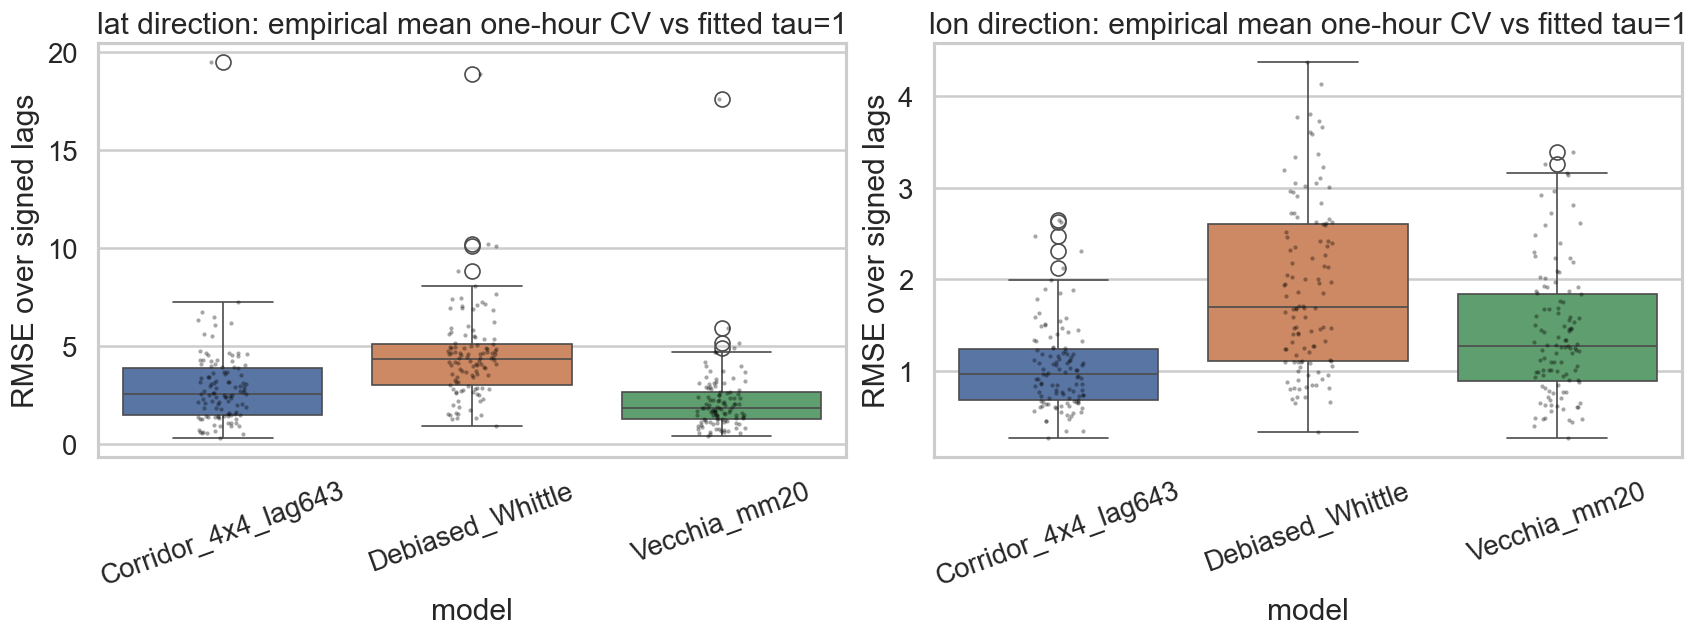

In [8]:
# Summary statistics: black empirical mean curve vs each fitted tau=1 model curve.
overall_error = (
    error_table
    .groupby(['direction', 'model'])
    .agg(
        n=('rmse', 'size'),
        rmse_mean=('rmse', 'mean'),
        rmse_median=('rmse', 'median'),
        mae_mean=('mae', 'mean'),
        mae_median=('mae', 'median'),
        bias_mean=('bias_emp_minus_fit', 'mean'),
        bias_median=('bias_emp_minus_fit', 'median'),
    )
    .round(4)
    .reset_index()
)
combined_error = (
    error_table
    .groupby('model')
    .agg(
        n=('rmse', 'size'),
        rmse_mean=('rmse', 'mean'),
        rmse_median=('rmse', 'median'),
        mae_mean=('mae', 'mean'),
        mae_median=('mae', 'median'),
        bias_mean=('bias_emp_minus_fit', 'mean'),
        bias_median=('bias_emp_minus_fit', 'median'),
    )
    .round(4)
    .reset_index()
)
by_year_direction = (
    error_table
    .groupby(['year', 'direction', 'model'])
    .agg(n=('rmse', 'size'), rmse_mean=('rmse', 'mean'), rmse_median=('rmse', 'median'))
    .round(4)
    .reset_index()
)

idx = error_table.groupby(['year', 'day_num', 'direction'])['rmse'].idxmin()
wins = error_table.loc[idx].groupby(['direction', 'model']).size().rename('wins').reset_index()

for name, table in [
    ('cross_variogram_model_error_summary_by_direction_2022_2025_07.csv', overall_error),
    ('cross_variogram_model_error_summary_combined_2022_2025_07.csv', combined_error),
    ('cross_variogram_model_error_by_year_direction_2022_2025_07.csv', by_year_direction),
    ('cross_variogram_model_wins_by_direction_2022_2025_07.csv', wins),
]:
    path = OUTPUT_DIR / name
    table.to_csv(path, index=False, float_format='%.4f')
    print(f'Saved {path}')

print('Combined error')
display(combined_error.sort_values('rmse_mean'))
print('Direction-specific error')
display(overall_error.sort_values(['direction', 'rmse_mean']))
print('Wins')
display(wins)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)
for ax, direction in zip(axes, ['lat', 'lon']):
    sub = error_table.loc[error_table['direction'].eq(direction)].copy()
    sns.boxplot(data=sub, x='model', y='rmse', hue='model', dodge=False, ax=ax)
    sns.stripplot(data=sub, x='model', y='rmse', color='black', alpha=0.35, size=2.5, ax=ax)
    if ax.legend_:
        ax.legend_.remove()
    ax.set_title(f'{direction} direction: empirical mean one-hour CV vs fitted tau=1')
    ax.set_xlabel('model')
    ax.set_ylabel('RMSE over signed lags')
    ax.tick_params(axis='x', rotation=20)
summary_plot = OUTPUT_DIR / 'cross_variogram_model_error_boxplot_2022_2025_07.png'
fig.savefig(summary_plot, bbox_inches='tight')
print(f'Saved {summary_plot}')
plt.show()


## Notes

- There are 7 blue curves per day because 8 hourly slots produce 7 adjacent one-hour pairs.
- The thick black curve is the pointwise average of those 7 empirical one-hour cross-variograms.
- The fitted curves use the same cross-variogram sign convention as the empirical calculation: `r(s,t) - r(s+h,t+1)`.
- At one-hour lag, fitted advection shifts the model minimum toward `h = v * tau`, so this diagnostic uses both spatial range/sill/nugget and advection.
- Numeric CSV outputs use 4 decimals.
